# Traitement d'images: 
## en analyse non supervisée
## en analyse semi-supervisée

In [ ]:
# === Data manipulation ===
import numpy as np
import pandas as pd

# === Visualisation ===
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# === Machine Learning===
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, adjusted_rand_score, f1_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN

# === Computer Vision ===
import cv2

# === Deep Learning (PyTorch) ===
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim

# === Deep Learning (TensorFlow / Keras) ===
import tensorflow as tf
keras = tf.keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.metrics import AUC, Precision, Recall

# === NLP / Transformers ===
from transformers import pipeline, AutoTokenizer, AutoModel

import os
import random
import hashlib
from collections import defaultdict

print ("imports terminés")


c:\Users\chris\traitement_images_semi_supervisées\venv312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


imports terminés


## Analyse Exploratoire des données

exploration visuelle et recheche d'images illisibles

In [4]:
dataset_path = "data/mri_dataset_brain_cancer_oc"

valid_ext = (".jpg", ".jpeg", ".png")

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if not os.path.isdir(class_path):
        continue

    for img_name in os.listdir(class_path):

        if not img_name.lower().endswith(valid_ext):
            continue

        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)

        if img is None:
            print("Image illisible :", img_path)

verification des dimensions de tout type d'images(avec et sans label)

In [ ]:
sizes = []
dataset_path = r"data/mri_dataset_brain_cancer_oc"

valid_extensions = (".jpg", ".jpeg", ".png")

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:]:
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            print("Image corrompue ou non lisible :", img_path)
            continue
        
        sizes.append(img.shape)

print("Tailles uniques :", set(sizes))

Tailles uniques : {(512, 512, 3)}


Vérification des doublons (par hashing avec chunks)

In [ ]:
dataset_path = r"data/mri_dataset_brain_cancer_oc"
valid_ext = (".png", ".jpg", ".jpeg")

hash_dict = defaultdict(list)

def get_hash(filepath):
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hasher.update(chunk)
    return hasher.hexdigest()


for root, dirs, files in os.walk(dataset_path):

    for file in files:

        if not file.lower().endswith(valid_ext):
            continue

        path = os.path.join(root, file)

        file_hash = get_hash(path)

        hash_dict[file_hash].append(path)


duplicates = {h: p for h, p in hash_dict.items() if len(p) > 1}

print("Nombre de groupes de doublons :", len(duplicates))

Doublons : 64


In [ ]:
for h, paths in duplicates.items():
    print("\nDoublon détecté :")
    for p in paths:
        print(p)

Supprimer les doublons

In [ ]:
deleted = 0

for paths in duplicates.values():

    # garder la première
    keep = paths[0]

    # supprimer les autres
    for p in paths[1:]:
        os.remove(p)
        deleted += 1
        print("Supprimé :", p)

print("Total supprimé :", deleted)

détection d’outliers

In [ ]:
means = []

for cls in os.listdir(dataset_path):

    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img = cv2.imread(os.path.join(class_path, img_name))

            if img is not None:
                means.append(img.mean())

print("Min :", np.min(means))
print("Max :", np.max(means))

Histogramme des intensités (détection d’outliers)

In [ ]:
plt.hist(means, bins=30)
plt.title("Distribution intensité moyenne des images")
plt.xlabel("Intensité moyenne")
plt.ylabel("Nombre d'images")
plt.show()

In [4]:
print(os.listdir(r"data\mri_dataset_brain_cancer_oc"))

['avec_labels', "Jeu de Données d'Images Cérébrales pour la Détection de Tumeurs.txt", 'sans_label']


Explorer les données labelisées (distribution des classes)

In [5]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    if os.path.isdir(class_path):
        print(cls, ":", len(os.listdir(class_path)), "images")

cancer : 50 images
normal : 50 images


tailles des images sur **données labelisées**

In [6]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
valid_extensions = (".jpg", ".jpeg", ".png")

sizes = []

for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    for img_name in images[:50]:  # on échantillonne
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        sizes.append(img.shape)

print("Tailles uniques trouvées :", set(sizes))

Tailles uniques trouvées : {(512, 512, 3)}


Affichage de quelques images labelisées par classe 

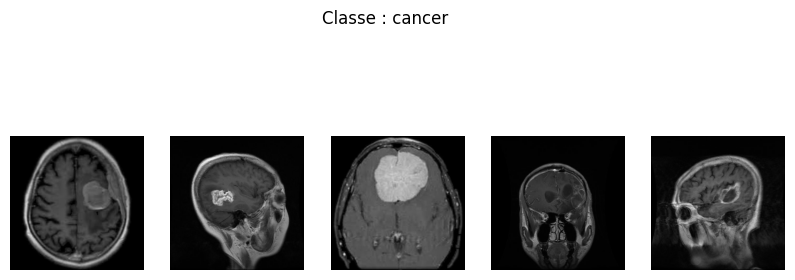

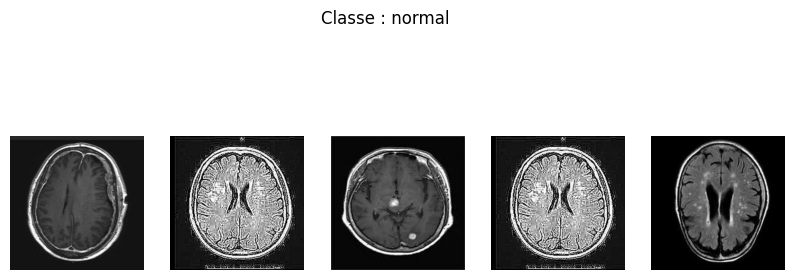

In [7]:
for cls in os.listdir(base_path):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]
    
    plt.figure(figsize=(10, 4))
    
    for i in range(5):  
        img_name = random.choice(images)
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        plt.subplot(1, 5, i+1)
        plt.imshow(img)
        plt.axis("off")
    
    plt.suptitle(f"Classe : {cls}")
    plt.show()

Resize en taille standard : 224x224 (ResNet)

In [8]:
img = cv2.imread(img_path)
img_resized = cv2.resize(img, (224, 224))

print("Nouvelle taille :", img_resized.shape)

Nouvelle taille : (224, 224, 3)


definition de X et y à partir des images labelisées

In [9]:
base_path = "data/mri_dataset_brain_cancer_oc/avec_labels"
img_size = 224

X = []
y = []

classes = sorted(os.listdir(base_path)) 
print("Classes :", classes)

for label, cls in enumerate(classes):
    class_path = os.path.join(base_path, cls)
    
    if not os.path.isdir(class_path):
        continue
    
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        
        if img is None:
            continue
        
        img = cv2.resize(img, (img_size, img_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        X.append(img)
        y.append(label)

Classes : ['cancer', 'normal']


50 images "cancer" et 50 images "normal"
X, les images et y, les labels (0,1)

normalisation en [0, 1] des pixels (de 0=noir à 255=blanc) des images (X)

In [10]:
X = np.array(X, dtype="float32") / 255.0   
y = np.array(y)

print(f"Dataset : {X.shape}, Labels : {y.shape}")

Dataset : (100, 224, 224, 3), Labels : (100,)


# analyse non supervisée

on va regarder si les images se partagent bien en 2 groupes (normal devrait etre séparé de cancer)

transformation des images en vecteur

In [11]:
X_features = X.reshape(X.shape[0], -1)

print(X_features.shape)

(100, 150528)


Standardisation des features avant réduction de dimension et clustering

In [12]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features)

Réduction de dimension avec PCA: ici 50 dimensions

In [13]:
pca = PCA(n_components=50)
X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(100, 50)


Visualisation avec t-SNE en 2D

In [14]:
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

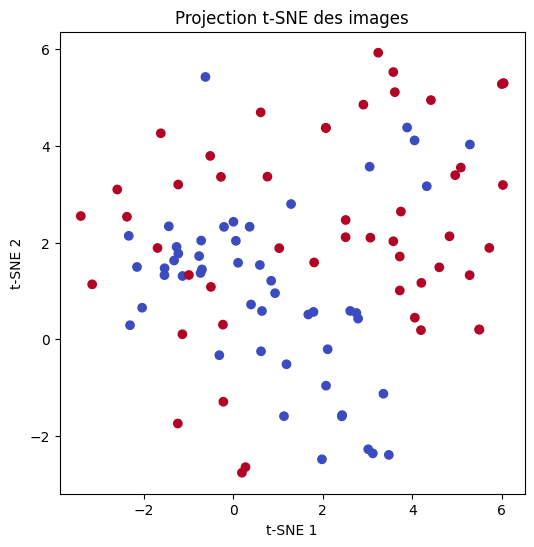

In [15]:
plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y, cmap="coolwarm")
plt.title("Projection t-SNE des images")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

=>très globalement, les 2 classes sont plutôt séparées

Clustering avec K-Means

In [16]:
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca)

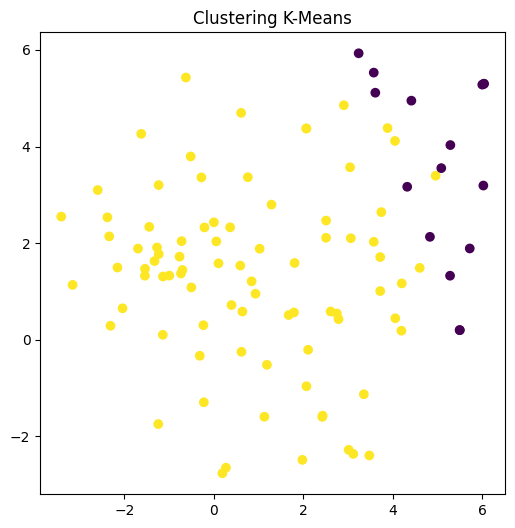

In [17]:
plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters, cmap="viridis")
plt.title("Clustering K-Means")
plt.show()

=> 2 groupes très inégaux sur les 100 images =>pertinence faible

Score ARI (Adjusted Rand Index)
comparaison clusters et labels

In [18]:
ari = adjusted_rand_score(y, clusters)

print("ARI score :", ari)

ARI score : 0.05245454102276605


=> clustering plutôt bon (>0.5) pour un petit data set (100 échantillons)

DBSCAN

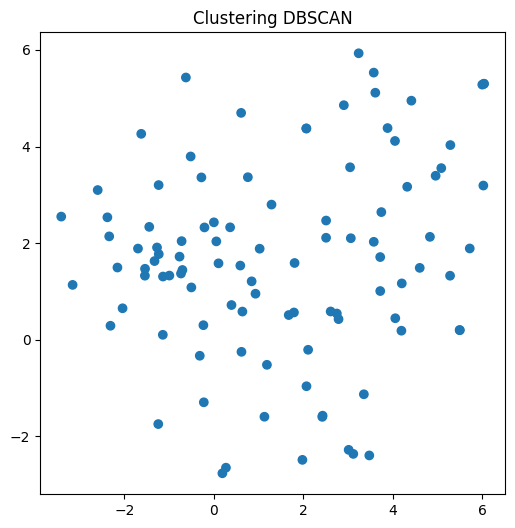

In [19]:
dbscan = DBSCAN(eps=5, min_samples=5)
clusters_db = dbscan.fit_predict(X_pca)

plt.figure(figsize=(6,6))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=clusters_db, cmap="tab10")
plt.title("Clustering DBSCAN")
plt.show()

=> DBSCAN peu adapté

# analyse semi supervise:

SPLIT TRAIN_TEST 

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train :", X_train.shape)
print("Test :", X_test.shape)

num_classes = len(classes)
print("Nombre de classes :", num_classes)

Train : (80, 224, 224, 3)
Test : (20, 224, 224, 3)
Nombre de classes : 2


# CNN 

In [26]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation="relu",input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation="relu"),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.5),

    layers.Dense(1,activation="sigmoid")  # ✔ correction
])


In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

In [28]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

11 millions de param pour 100 images => overfit 

In [29]:
print(y_train.shape)
print(np.unique(y_train))

(80,)
[0 1]


entraînement

In [30]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.5000 - loss: 1.8179 - precision: 0.5294 - recall: 0.4737 - roc_auc: 0.4547 - val_accuracy: 0.5000 - val_loss: 0.6868 - val_precision: 0.2500 - val_recall: 0.5000 - val_roc_auc: 0.5000
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 718ms/step - accuracy: 0.5694 - loss: 0.6862 - precision: 0.5814 - recall: 0.6579 - roc_auc: 0.6602 - val_accuracy: 0.2500 - val_loss: 0.7919 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 794ms/step - accuracy: 0.5278 - loss: 0.6271 - precision: 0.5278 - recall: 1.0000 - roc_auc: 0.8220 - val_accuracy: 0.2500 - val_loss: 0.8138 - val_precision: 0.2500 - val_recall: 1.0000 - val_roc_auc: 0.7917
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 734ms/step - accuracy: 0.6389 - loss: 0.6081 - precision: 0.5968 - recall: 0.9737 - roc_auc: 0.8224 - val_accuracy: 0.3750 - val_loss: 0.7145 - val_precision: 0.2857 - val_recall: 1.0000 - val_roc_auc: 0.8333
Epoch 5/10


metriques

In [31]:
loss, accuracy, roc_auc, precision, recall = model.evaluate(X_test, y_test, verbose=0)

print(f"\nBaseline accuracy : {accuracy*100:.2f}%")
print(f"Loss              : {loss:.4f}")
print(f"ROC AUC           : {roc_auc:.4f}")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")


Baseline accuracy : 90.00%
Loss              : 0.4183
ROC AUC           : 0.9300
Precision         : 0.9000
Recall            : 0.9000


data augmentation car seulement 100 echantillons avac labels

In [32]:
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

transfer learning avec ResNet50

In [33]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False  # on gèle les couches

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # binaire
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy",
        AUC(name="roc_auc"),
        Precision(name="precision"),
        Recall(name="recall")]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,718,913 (90.48 MB)

 Trainable params: 131,201 (512.50 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

2 classes =>obtenir un neurone final

In [34]:
y = np.array(y).astype("float32")

In [35]:
history = model.fit(
    datagen.flow(X_train, y_train, batch_size=8),
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 21s 1s/step - accuracy: 0.6500 - loss: 0.7110 - precision: 0.6667 - recall: 0.6000 - roc_auc: 0.6391 - val_accuracy: 0.5000 - val_loss: 0.7087 - val_precision: 0.5000 - val_recall: 1.0000 - val_roc_auc: 0.8450
Epoch 2/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 845ms/step - accuracy: 0.6000 - loss: 0.7850 - precision: 0.5714 - recall: 0.8000 - roc_auc: 0.6181 - val_accuracy: 0.7500 - val_loss: 0.5605 - val_precision: 0.7778 - val_recall: 0.7000 - val_roc_auc: 0.8700
Epoch 3/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 8s 868ms/step - accuracy: 0.5625 - loss: 0.7333 - precision: 0.6087 - recall: 0.3500 - roc_auc: 0.5931 - val_accuracy: 0.8000 - val_loss: 0.5390 - val_precision: 0.8000 - val_recall: 0.8000 - val_roc_auc: 0.8650
Epoch 4/20
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 955ms/step - accuracy: 0.6375 - loss: 0.6848 - precision: 0.5873 - recall: 0.9250 - roc_auc: 0.6975 - val_accuracy: 0.7500 - val_loss: 0.5407 - val_precision: 0.7273 - val_recall: 0.8000 - val_roc_auc: 0.8800
E

predictions sur images sans label

In [36]:
unlabeled_path = "data/mri_dataset_brain_cancer_oc/sans_label"

X_unlabeled = []

for img_name in os.listdir(unlabeled_path):
    img_path = os.path.join(unlabeled_path, img_name)
    img = cv2.imread(img_path)
    
    if img is None:
        continue
    
    img = cv2.resize(img, (224, 224))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    X_unlabeled.append(img)

X_unlabeled = np.array(X_unlabeled, dtype="float32") / 255.0

print("Unlabeled shape:", X_unlabeled.shape)

Unlabeled shape: (1406, 224, 224, 3)


modele semi supervise

In [37]:
pseudo_probs = model.predict(X_unlabeled)

44/44 ━━━━━━━━━━━━━━━━━━━━ 105s 2s/step


In [38]:
pseudo_labels = (pseudo_probs > 0.9).astype(int)

True quand l'une des 2 conditions est vraie avec mask
On garde seulement les prédictions très confiantes

In [ ]:
mask = (pseudo_probs > 0.9) | (pseudo_probs < 0.1) 

X_pseudo = X_unlabeled[mask.flatten()]
y_pseudo = (pseudo_probs[mask] > 0.5).astype(int)

y_pseudo = y_pseudo.flatten() # pour avoir 1 seule dimension et non pas 2

In [40]:
print("y_train shape:", y_train.shape)
print("y_pseudo shape:", y_pseudo.shape)

y_train shape: (80,)
y_pseudo shape: (103,)


In [41]:
X_combined = np.concatenate([X_train, X_pseudo])
y_combined = np.concatenate([y_train, y_pseudo])

print(X_combined.shape)
print(y_combined.shape)

(183, 224, 224, 3)
(183,)


entrainement à nouveau

In [42]:
history_ssl = model.fit(
    X_combined, y_combined,
    epochs=10,
    validation_data=(X_test, y_test),
    batch_size=8
)

Epoch 1/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 678ms/step - accuracy: 0.8798 - loss: 0.2400 - precision: 0.9291 - recall: 0.9161 - roc_auc: 0.9428 - val_accuracy: 0.7500 - val_loss: 0.4624 - val_precision: 0.7778 - val_recall: 0.7000 - val_roc_auc: 0.8950
Epoch 2/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 728ms/step - accuracy: 0.9071 - loss: 0.2430 - precision: 0.9632 - recall: 0.9161 - roc_auc: 0.9424 - val_accuracy: 0.7500 - val_loss: 0.5517 - val_precision: 0.7273 - val_recall: 0.8000 - val_roc_auc: 0.8900
Epoch 3/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 693ms/step - accuracy: 0.8962 - loss: 0.2084 - precision: 0.9247 - recall: 0.9441 - roc_auc: 0.9604 - val_accuracy: 0.7500 - val_loss: 0.4628 - val_precision: 0.7778 - val_recall: 0.7000 - val_roc_auc: 0.8950
Epoch 4/10
23/23 ━━━━━━━━━━━━━━━━━━━━ 16s 674ms/step - accuracy: 0.9180 - loss: 0.2167 - precision: 0.9507 - recall: 0.9441 - roc_auc: 0.9554 - val_accuracy: 0.7500 - val_loss: 0.4973 - val_precision: 0.7778 - val_recall: 0.7000 - val_roc_auc: 0.8

In [43]:
print("Nombre pseudo-labels retenus :", len(X_pseudo))

Nombre pseudo-labels retenus : 103


entrainemet successif

In [44]:
def semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=5,
    batch_size=8,
    epochs=5
):

    X_labeled = X_train.copy()
    y_labeled = y_train.copy()

    for i in range(iterations):

        print(f"\n===== Iteration {i+1} =====")

        # prédictions sur données non labelisées
        preds = model.predict(X_unlabeled)

        # sélection forte confiance
        high_conf_mask = (preds > confidence_threshold) | (preds < (1 - confidence_threshold))

        X_pseudo = X_unlabeled[high_conf_mask.flatten()]
        y_pseudo = (preds[high_conf_mask] > 0.5).astype(int).flatten()

        print(f"Pseudo labels retenus : {len(y_pseudo)}")

        if len(y_pseudo) == 0:
            print("Aucun pseudo label fiable, arrêt.")
            break

        # ajout au dataset
        X_labeled = np.concatenate([X_labeled, X_pseudo])
        y_labeled = np.concatenate([y_labeled, y_pseudo])

        # retirer ces images du pool non labelisé
        X_unlabeled = X_unlabeled[~high_conf_mask.flatten()]

        print(f"Dataset train actuel : {X_labeled.shape}")

        # réentrainement
        model.fit(
            X_labeled,
            y_labeled,
            epochs=epochs,
            batch_size=batch_size,
            verbose=1
        )

        # évaluations succesives
        loss, acc, roc_auc, precision, recall = model.evaluate(X_test, y_test, verbose=0)

        print("\nEvaluation :")
        print(f"Accuracy  : {acc:.4f}")
        print(f"ROC AUC   : {roc_auc:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")

    return model

lancement de cette derniere fonction

In [45]:
model = semi_supervised_training(
    model,
    X_train,
    y_train,
    X_unlabeled,
    X_test,
    y_test,
    confidence_threshold=0.95,
    iterations=10,
    epochs=5
)


===== Iteration 1 =====
44/44 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step
Pseudo labels retenus : 155
Dataset train actuel : (235, 224, 224, 3)
Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 589ms/step - accuracy: 0.9362 - loss: 0.1572 - precision: 0.9737 - recall: 0.9487 - roc_auc: 0.9663
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 612ms/step - accuracy: 0.9404 - loss: 0.1478 - precision: 0.9840 - recall: 0.9436 - roc_auc: 0.9772
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 564ms/step - accuracy: 0.9277 - loss: 0.1509 - precision: 0.9635 - recall: 0.9487 - roc_auc: 0.9728
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 580ms/step - accuracy: 0.9362 - loss: 0.1422 - precision: 0.9839 - recall: 0.9385 - roc_auc: 0.9743
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 18s 588ms/step - accuracy: 0.9234 - loss: 0.1559 - precision: 0.9538 - recall: 0.9538 - roc_auc: 0.9684

Evaluation :
Accuracy  : 0.7500
ROC AUC   : 0.9000
Precision : 0.7778
Recall    : 0.7000

===== Iteration 2 =====
40/40 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step
Pseudo 